Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
E: Unable to locate package fonts-sipa-arundhati
กำลังสร้างชุดข้อมูลฉบับแก้ปัญหาเลข ๕๖...
กำลังสร้างคลาส ๕๖...
กำลังสร้างคลาส ๕๗...
กำลังสร้างคลาส ๕๘...
กำลังสร้างคลาส ๕๙...
กำลังสร้างคลาส ๖๐...
------------------------------
สร้างข้อมูลเสร็จสิ้น! แนะนำให้รันการ Train ใหม่ (Re-train) ทั้งหมดครับ


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3669 (\N{THAI DIGIT FIVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3670 (\N{THAI DIGIT SIX}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


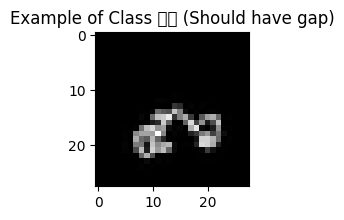

In [11]:
import os, random, shutil, numpy as np, matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont, ImageOps

# 1. ติดตั้งฟอนต์
!apt-get install -y fonts-thai-tlwg fonts-sipa-arundhati

CLASSES = ['๕๖', '๕๗', '๕๘', '๕๙', '๖๐']
DATA_DIR = 'dataset_thai_v4' # เปลี่ยนชื่อโฟลเดอร์เพื่อความสดใหม่
NUM_SAMPLES_PER_CLASS = 2500

FONT_PATHS = [
    "/usr/share/fonts/truetype/thai-tlwg/Loma.ttf",
    "/usr/share/fonts/truetype/thai-tlwg/Purisa.ttf",
    "/usr/share/fonts/truetype/thai-tlwg/Waree.ttf",
    "/usr/share/fonts/truetype/thai-tlwg/Kinnari.ttf",
    "/usr/share/fonts/truetype/thai-tlwg/Norasi.ttf"
]

if os.path.exists(DATA_DIR): shutil.rmtree(DATA_DIR)
for c in CLASSES: os.makedirs(os.path.join(DATA_DIR, c), exist_ok=True)

def create_final_image(text, save_path):
    # เริ่มด้วยภาพขนาดใหญ่ 56x56
    img = Image.new('L', (56, 56), color=0)
    draw = ImageDraw.Draw(img)

    f_path = random.choice(FONT_PATHS)

    # --- แก้ไขตรงนี้: ลดขนาดฟอนต์ลงเพื่อให้ตัวเลขมีพื้นที่ว่าง ไม่เบียดกัน ---
    # ขนาด 22-26 ในเฟรม 56 จะเท่ากับประมาณ 11-13 ในเฟรม 28 (ผอมลงชัดเจน)
    font_size = random.randint(22, 26)
    font = ImageFont.truetype(f_path, font_size)

    # จัดกึ่งกลาง
    left, top, right, bottom = draw.textbbox((0, 0), text, font=font)
    w, h = right - left, bottom - top

    # สุ่มตำแหน่งเบาๆ ไม่ให้กระเด็นติดขอบ
    x = (56 - w) // 2 + random.randint(-2, 2)
    y = (56 - h) // 2 + random.randint(-2, 2)

    draw.text((x, y), text, fill=255, font=font)

    # --- แก้ไขตรงนี้: ลดแรงหมุนลงเพื่อรักษาทรง "หาง" ของเลข ๖ และ ๗ ---
    img = img.rotate(random.randint(-10, 10))

    # ย่อกลับมาที่ 28x28
    img = img.resize((28, 28), Image.LANCZOS) # ใช้ LANCZOS เพื่อให้เส้นเนียนขึ้น

    # เพิ่ม Noise เล็กน้อย (ปรับให้ Noise เบาลงเพื่อไม่ให้กวนหัวตัวเลข)
    img_array = np.array(img)
    if random.random() > 0.7: # ลดโอกาสเกิด noise
        noise = np.random.normal(0, 3, img_array.shape)
        img_array = np.clip(img_array.astype(float) + noise, 0, 255).astype('uint8')

    Image.fromarray(img_array).save(save_path)

print("กำลังสร้างชุดข้อมูลฉบับแก้ปัญหาเลข ๕๖...")
for text in CLASSES:
    print(f"กำลังสร้างคลาส {text}...")
    for i in range(NUM_SAMPLES_PER_CLASS):
        create_final_image(text, os.path.join(DATA_DIR, text, f"{text}_{i}.png"))

print("-" * 30)
print(f"สร้างข้อมูลเสร็จสิ้น! แนะนำให้รันการ Train ใหม่ (Re-train) ทั้งหมดครับ")

# แสดงตัวอย่างเพื่อเช็คว่าเลข ๕๖ มีช่องว่างตรงกลางไหม
plt.figure(figsize=(10, 2))
sample_56 = os.listdir(os.path.join(DATA_DIR, '๕๖'))[0]
img_sample = Image.open(os.path.join(DATA_DIR, '๕๖', sample_56))
plt.imshow(img_sample, cmap='gray')
plt.title("Example of Class ๕๖ (Should have gap)")
plt.show()

# --- คำสั่งสำหรับ Zip ไฟล์เผื่อต้องการโหลดลงเครื่อง (Optional) ---
# !zip -r dataset_thai_numbers.zip dataset_thai_numbers/

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. ตั้งค่าโฟลเดอร์ให้ตรงกับที่เราเพิ่งสร้างใหม่
DATA_DIR = 'dataset_thai_v4'

# 2. ปรับ Augmentation ให้ "สมดุล"
# ไม่ให้เลขบิดเบี้ยวจนหัวและตัวเลขมาทับกันเอง
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,      # ลดลงเล็กน้อยเพื่อรักษาทรงเลข ๖ ไม่ให้เหมือน ๗
    width_shift_range=0.1,  # ลดลงเพื่อไม่ให้เลขหลุดขอบ
    height_shift_range=0.1,
    shear_range=0.2,        # การเอียงพอประมาณช่วยแยกหาง ๗ และ ๙
    zoom_range=0.1,         # ลดการซูมลงเพื่อไม่ให้ตัวเลขขยายจนเบียดกัน
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    DATA_DIR,
    target_size=(28, 28),
    color_mode='grayscale',
    batch_size=32,
    class_mode='sparse',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    DATA_DIR,
    target_size=(28, 28),
    color_mode='grayscale',
    batch_size=32,
    class_mode='sparse',
    subset='validation'
)

# 3. โครงสร้าง Model (ใช้ตัวที่คุณส่งมา ซึ่งถือว่ามีประสิทธิภาพสูงอยู่แล้ว)
model = models.Sequential([
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(28, 28, 1)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(CLASSES), activation='softmax')
])

# 4. ใช้ Adam Optimizer พร้อมกับ Learning Rate ที่เหมาะสม
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. เพิ่ม EarlyStopping (Optional) เพื่อหยุดเทรนถ้าแม่นยำที่สุดแล้ว
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# เริ่มต้นการเทรน
print("Starting training with fine-tuned dataset...")
history = model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    callbacks=[early_stop]
)

model.save('thai_ultimate_model_v4.h5')
print("Model saved as thai_ultimate_model_v4.h5")

Found 10000 images belonging to 5 classes.
Found 2500 images belonging to 5 classes.
Starting training with fine-tuned dataset...
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 116ms/step - accuracy: 0.8640 - loss: 0.4032 - val_accuracy: 0.4744 - val_loss: 1.3174
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 116ms/step - accuracy: 0.9929 - loss: 0.0201 - val_accuracy: 0.9880 - val_loss: 0.0336
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 117ms/step - accuracy: 0.9953 - loss: 0.0125 - val_accuracy: 0.9980 - val_loss: 0.0058
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.9927 - loss: 0.0253 - val_accuracy: 0.9812 - val_loss: 0.0690
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.9978 - loss: 0.0082 - val_accuracy: 0.9936 - val_loss: 0.0197
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.9977 - loss: 0.0078 - val_accuracy: 0.9992 - val_loss: 0.0014
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.9971 - loss: 0.0093 - val_accuracy: 0.9732 - val_loss: 0.1711
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.9973 - loss: 0.0104 - val

Model saved as thai_ultimate_model_v4.h5


In [14]:
!pip install gradio -q
import gradio as gr, cv2, numpy as np

def classify_thai_final_v4(img):
    if img is None: return None

    # 1. จัดการ Input จาก Gradio (ตรวจสอบว่าเป็นภาพวาดหรือไม่)
    # Gradio เวอร์ชันใหม่มักจะให้มาเป็น dict ที่มี key 'composite' หรือ 'layers'
    if isinstance(img, dict):
        img = img['composite']

    # 2. แปลงเป็น Grayscale
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # 3. ตรวจสอบสีพื้นหลัง (ต้องเป็นพื้นดำ ตัวเลขขาว)
    if np.mean(img) > 127:
        img = cv2.bitwise_not(img)

    # 4. กำจัด Noise และทำให้เส้นคมชัด
    _, img = cv2.threshold(img, 40, 255, cv2.THRESH_BINARY)

    # --- ใช้ Erode เพื่อหดเส้นให้ผอมลงเล็กน้อย ช่วยแยกเลข ๕ กับ ๖ ---
    kernel = np.ones((2,2), np.uint8)
    img = cv2.erode(img, kernel, iterations=1)

    # 5. เตรียมภาพเข้า Model
    img_resized = cv2.resize(img, (28, 28))
    img_input = img_resized.astype('float32') / 255.0
    img_input = np.expand_dims(img_input, axis=(0, -1))

    # 6. Predict (ใช้ชื่อโมเดลล่าสุดที่คุณเทรน)
    pred = model.predict(img_input, verbose=0)[0]

    return {CLASSES[i]: float(pred[i]) for i in range(len(CLASSES))}

# สร้าง UI ใหม่ (ตัด brush_radius ออกเพื่อแก้ TypeError)
demo = gr.Interface(
    fn=classify_thai_final_v4,
    inputs=gr.Sketchpad(
        label="วาด ๕๖, ๕๗, ๕๘, ๕๙, ๖๐",
        type="numpy"
    ),
    outputs=gr.Label(num_top_classes=5, label="ผลการวิเคราะห์"),
    title="Thai Handwriting Recognition V4",
    description="เน้นวาดตัวเลขให้มีช่องว่างระหว่างกัน และตวัดหางให้ชัดเจน"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://69767de63e552126d4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import shutil
import os
# ลบ Folder ทิ้งให้หมดเพื่อเริ่มใหม่
if os.path.exists('dataset_thai_numbers'):
    shutil.rmtree('dataset_thai_numbers')
    print("ลบข้อมูลเก่าเรียบร้อย!")

ลบข้อมูลเก่าเรียบร้อย!
